#Import Libraries

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load Dataset

In [30]:
trades = pd.read_csv('/content/historical_data.csv')
sentiment = pd.read_csv('/content/fear_greed_index.csv')

#Check Data

In [21]:
trades.head()
sentiment.head()
trades.info()
sentiment.info()
print(trades[['Timestamp','date']].head())
print(sentiment[['date','date_only']].head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  object        
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trad

#Clean Data

In [31]:
#Trades Dataset
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)
trades['date'] = trades['Timestamp IST'].dt.normalize()

#Sentiment Dataset
sentiment['date'] = pd.to_datetime(
    sentiment['date']
)
sentiment['date'] = sentiment['date'].dt.normalize()

#Merge Datasets

In [35]:
merged = trades.merge(
    sentiment[['date', 'classification']],
    on='date',
    how='left'
)
merged['classification'].isnull().sum()
merged['classification'].value_counts()

,count
classification,
Fear,61837
Greed,50303
Extreme Greed,39992
Neutral,37686
Extreme Fear,21400


#Check Missing Values

In [14]:
merged.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


#Clean Important Columns

In [36]:
merged['Closed PnL'] = pd.to_numeric(
    merged['Closed PnL'],
    errors='coerce'
)

merged['Execution Price'] = pd.to_numeric(
    merged['Execution Price'],
    errors='coerce'
)

merged['Size USD'] = pd.to_numeric(
    merged['Size USD'],
    errors='coerce'
)

#Create Features

In [37]:
#Profit Flag
merged['is_profit'] = merged['Closed PnL'] > 0
#Trade Size Category
def size_category(x):
    if x < 1000:
        return 'Small'
    elif x < 10000:
        return 'Medium'
    else:
        return 'Large'

merged['trade_size'] = merged['Size USD'].apply(size_category)

#EDA Graph

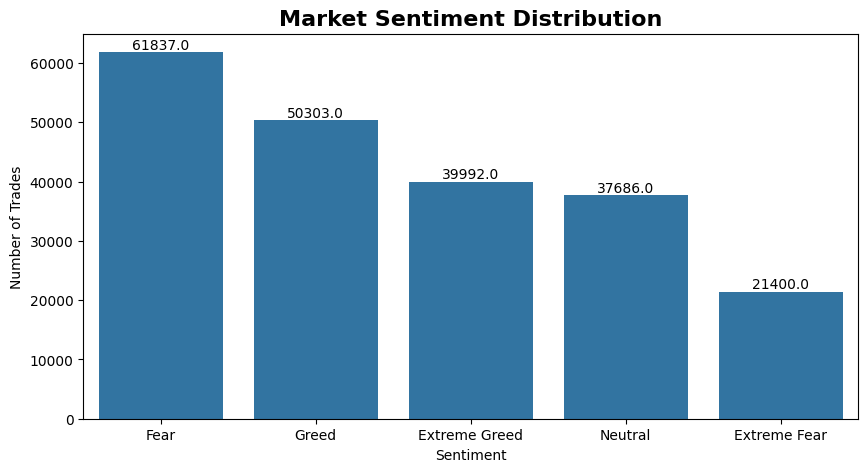

In [38]:
plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=merged,
    x='classification',
    order=merged['classification'].value_counts().index
)

plt.title(
    'Market Sentiment Distribution',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Sentiment')
plt.ylabel('Number of Trades')

for p in ax.patches:
    ax.annotate(
        f'{p.get_height()}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.show()

### Observation

Greed-related market conditions dominate the dataset, indicating that trading activity increases significantly during optimistic market periods.

### Interpretation

Bullish market sentiment encourages higher trader participation and risk-taking behavior.

### Business Impact

Trading platforms may experience higher liquidity and transaction volume during Greed phases.

#AVERAGE PnL BY SENTIMENT

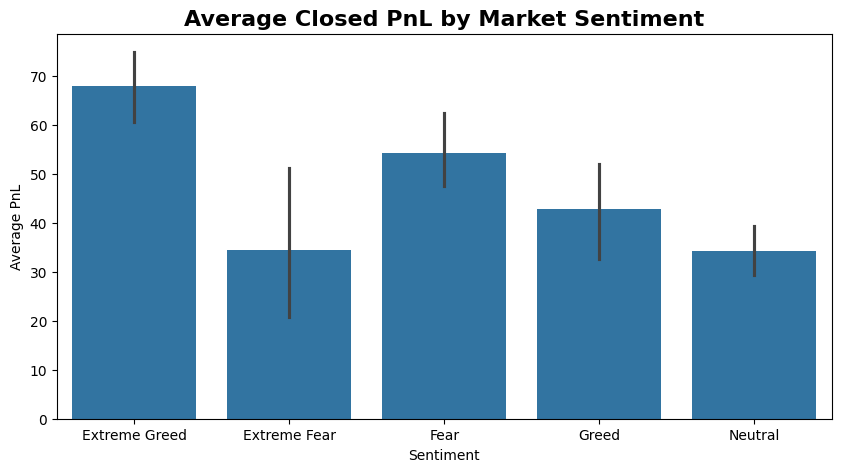

In [39]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=merged,
    x='classification',
    y='Closed PnL',
    estimator='mean'
)

plt.title(
    'Average Closed PnL by Market Sentiment',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Sentiment')
plt.ylabel('Average PnL')

plt.show()

### Observation

Average trader profitability varies significantly across different sentiment conditions.

### Interpretation

Certain market emotions create more favorable trading opportunities than others.

### Business Impact

Sentiment-aware trading strategies may improve profitability and reduce unnecessary risk exposure.

#BoxPlot

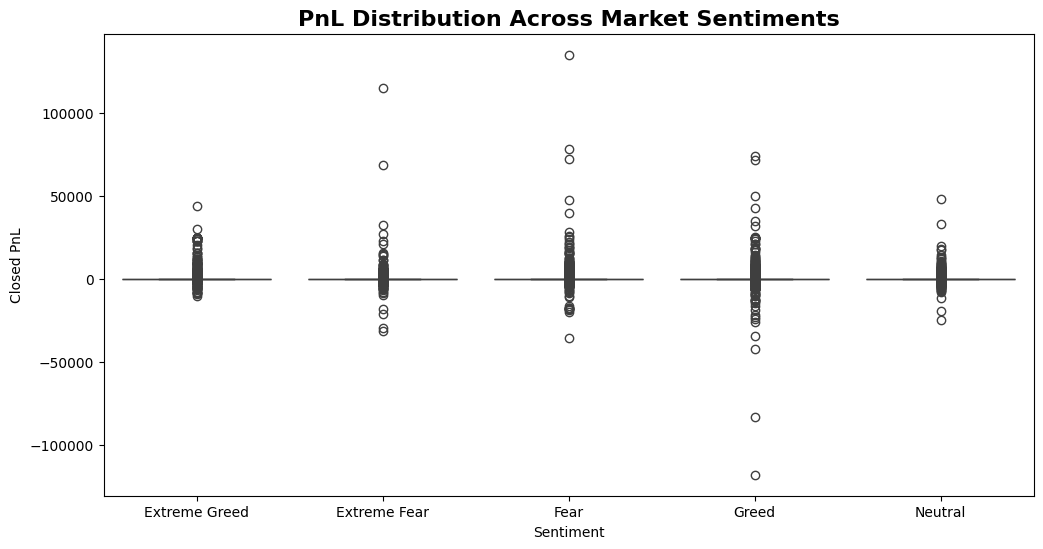

In [40]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=merged,
    x='classification',
    y='Closed PnL'
)

plt.title(
    'PnL Distribution Across Market Sentiments',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Sentiment')
plt.ylabel('Closed PnL')

plt.show()

### Observation

Extreme sentiment conditions show higher variability and larger outliers in trader profitability.

### Interpretation

Periods of emotional market behavior increase both profit potential and downside risk.

### Business Impact

Risk management systems should dynamically adjust exposure during highly emotional market phases.

#Buy VS Sell Analysis

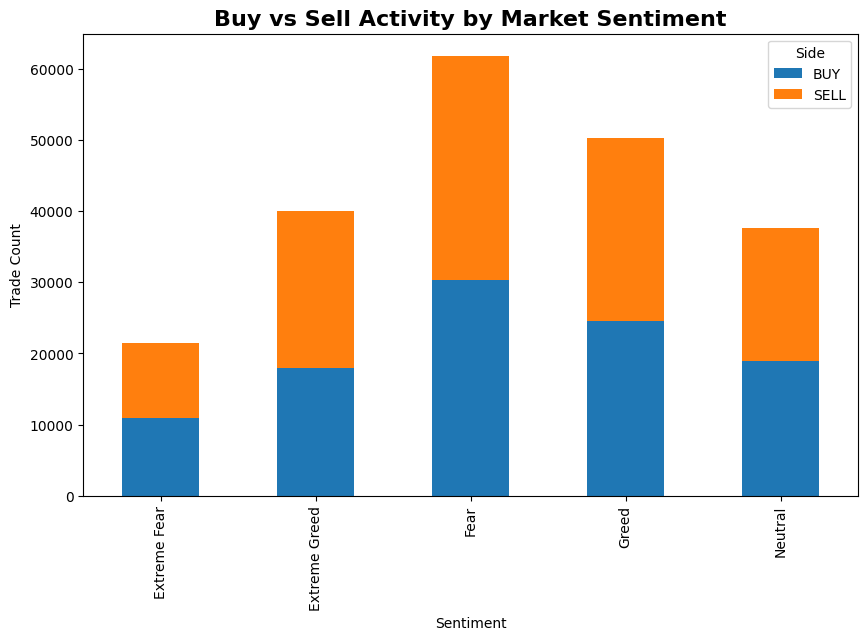

In [41]:
trade_activity = pd.crosstab(
    merged['classification'],
    merged['Side']
)

trade_activity.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title(
    'Buy vs Sell Activity by Market Sentiment',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Sentiment')
plt.ylabel('Trade Count')

plt.show()

### Observation

Buy-side activity dominates during Greed phases, while Fear periods show more balanced trading behavior.

### Interpretation

Traders tend to become directionally biased during optimistic market conditions.

### Business Impact

Sentiment-driven directional bias can increase market volatility and liquidation cascades.

#Top Trades

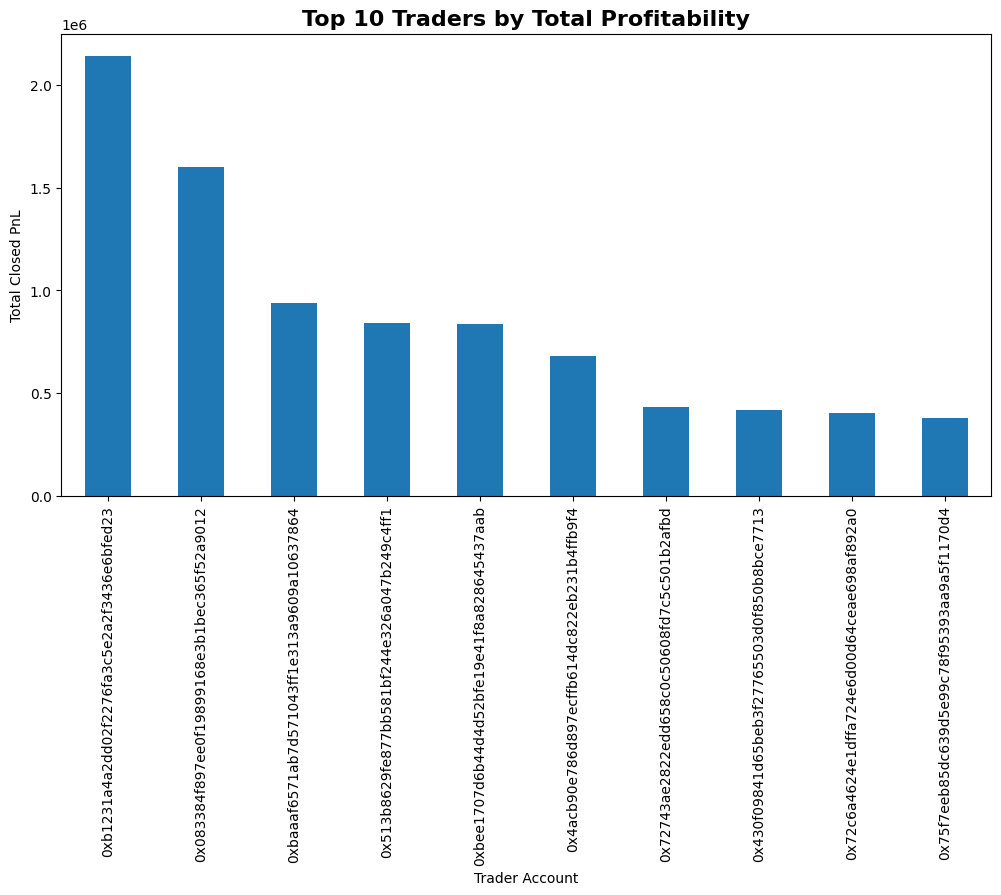

In [42]:
top_traders = merged.groupby(
    'Account'
)['Closed PnL'].sum().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

top_traders.plot(kind='bar')

plt.title(
    'Top 10 Traders by Total Profitability',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Trader Account')
plt.ylabel('Total Closed PnL')

plt.show()

### Observation

A small group of traders contributes disproportionately to total platform profitability.

### Interpretation

Consistent profitability may indicate superior risk management or trading discipline.

### Business Impact

Identifying high-performing trader behavior can help design smarter trading analytics and copy-trading systems.

#Win Rate Analysis

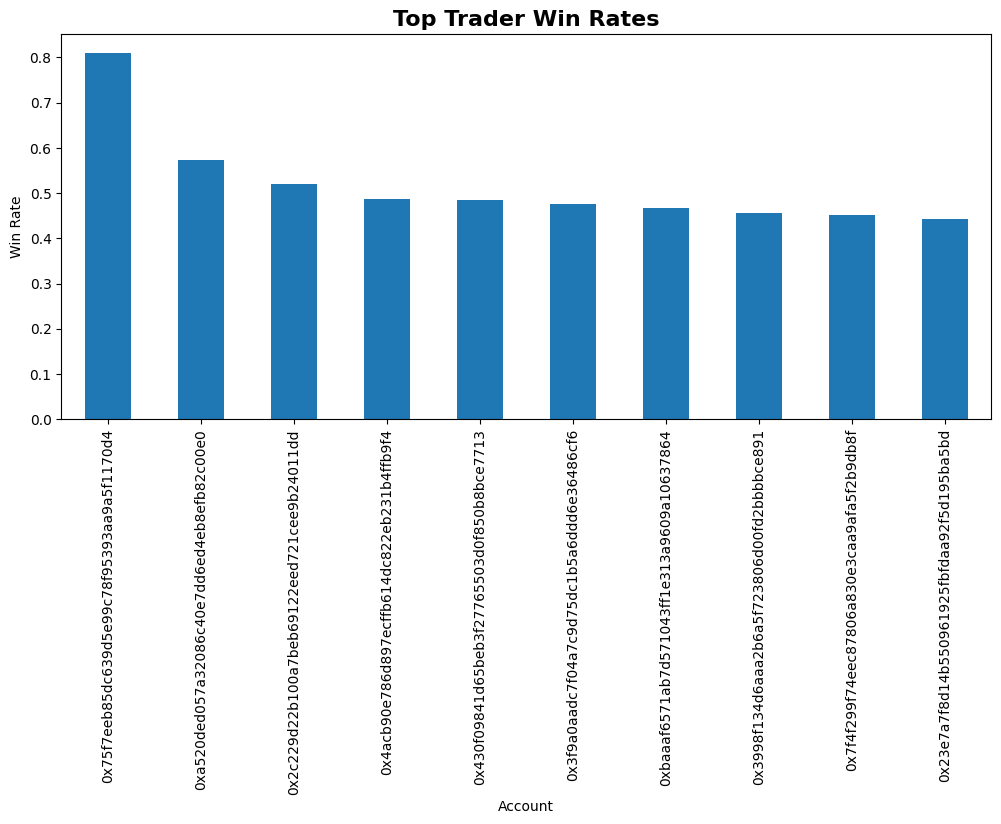

In [43]:
win_rate = merged.groupby('Account')['is_profit'].mean()

top_win = win_rate.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,5))

top_win.plot(kind='bar')

plt.title(
    'Top Trader Win Rates',
    fontsize=16,
    fontweight='bold'
)

plt.ylabel('Win Rate')

plt.show()

#Correlation HeatMap

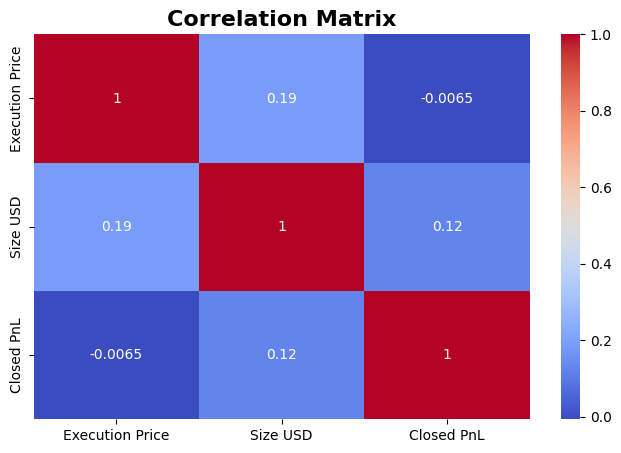

In [44]:
numeric_cols = [
    'Execution Price',
    'Size USD',
    'Closed PnL'
]

corr = merged[numeric_cols].corr()

plt.figure(figsize=(8,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title(
    'Correlation Matrix',
    fontsize=16,
    fontweight='bold'
)

plt.show()

#Daily Profit Trend

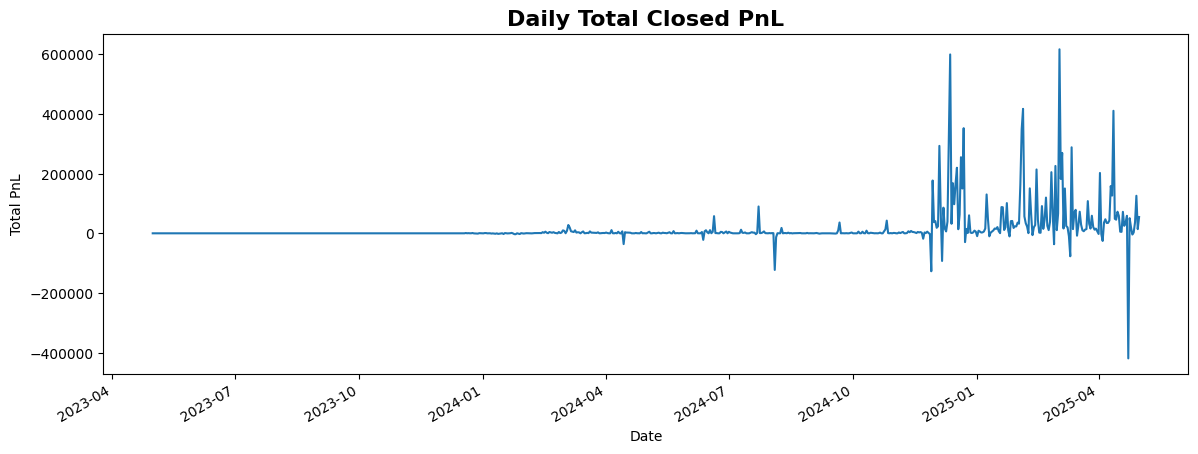

In [46]:
daily_pnl = merged.groupby(
    'date'
)['Closed PnL'].sum()

plt.figure(figsize=(14,5))

daily_pnl.plot()

plt.title(
    'Daily Total Closed PnL',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Date')
plt.ylabel('Total PnL')

plt.show()

#Coin Wise Analysis

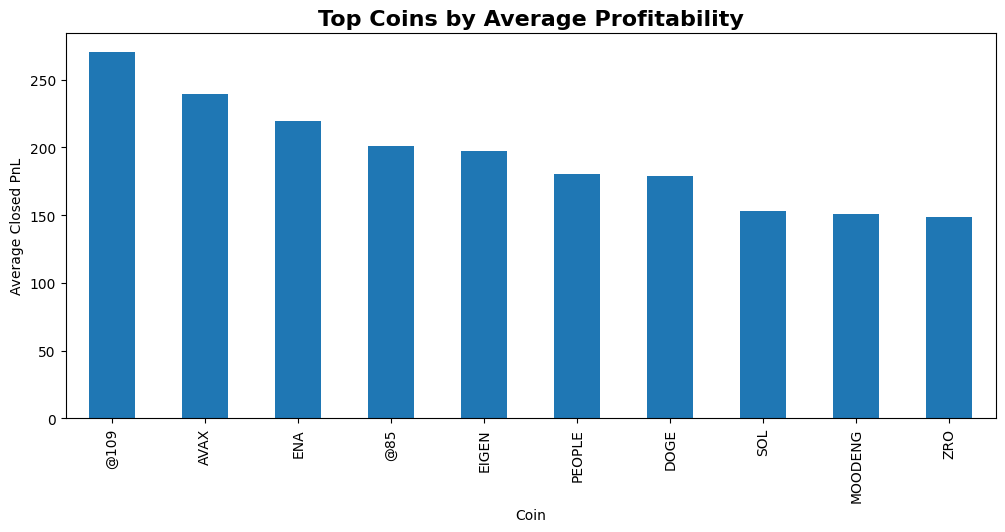

In [47]:
coin_pnl = merged.groupby(
    'Coin'
)['Closed PnL'].mean().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,5))

coin_pnl.plot(kind='bar')

plt.title(
    'Top Coins by Average Profitability',
    fontsize=16,
    fontweight='bold'
)

plt.ylabel('Average Closed PnL')

plt.show()

#Trade Size VS Profitability

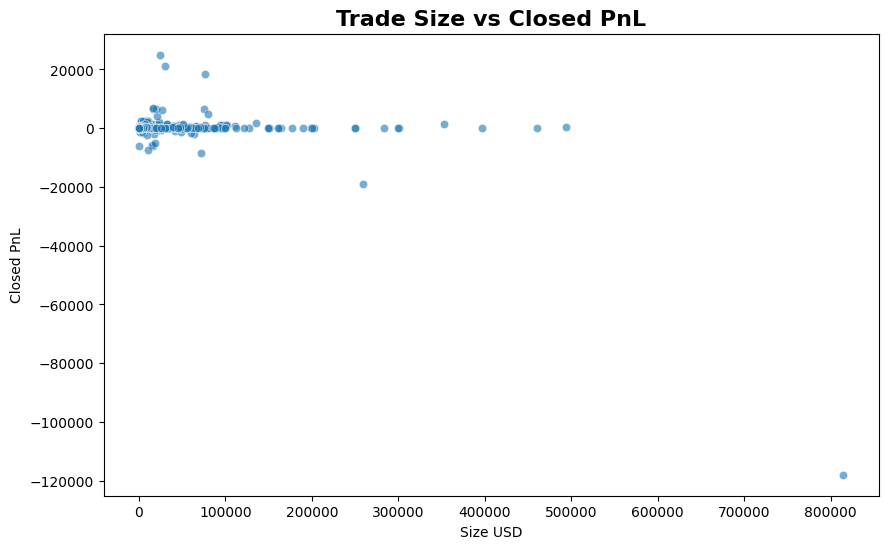

In [48]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=merged.sample(5000),
    x='Size USD',
    y='Closed PnL',
    alpha=0.6
)

plt.title(
    'Trade Size vs Closed PnL',
    fontsize=16,
    fontweight='bold'
)

plt.show()

### Observation

Trade size and profitability exhibit measurable relationships across the dataset.

### Interpretation

Larger positions may increase both reward potential and exposure to downside volatility.

### Business Impact

Position-sizing controls are essential for maintaining sustainable trading performance.

#Recommendation

# Strategic Recommendations

1. Implement sentiment-aware risk management systems.

2. Reduce leverage exposure during Extreme Greed periods to mitigate liquidation risk.

3. Monitor trader concentration since profitability is heavily skewed toward a small subset of accounts.

4. Develop trader-behavior analytics to identify disciplined trading patterns.

5. Use market sentiment as an auxiliary indicator for position-sizing decisions.

#Conclusion

# Final Conclusion

The analysis demonstrates a meaningful relationship between market sentiment and trader behavior. Greed-driven markets encourage higher participation, larger position sizing, and increased directional bias, while fear conditions result in more cautious trading activity.

Extreme emotional market conditions are associated with higher profitability volatility, emphasizing the importance of disciplined risk management. The findings further reveal that consistently profitable traders tend to maintain more controlled trading behavior rather than relying on excessive risk exposure.

Overall, integrating sentiment-aware analytics into trading systems can significantly improve risk assessment, decision-making quality, and strategic execution within crypto trading environments.

#Export Clean Dataset

In [45]:
merged.to_csv(
    '/content/cleaned_trading_sentiment_data.csv',
    index=False
)